**Author:** Biswajit Jana
**Date:** June 4, 2026

# M87 morphology in an HST preview image

**Date:** 2026-07-31  
**Scientific question:** What centroid, ellipticity, and half-light radius are measured from the preserved HST preview?  
**Preserved source:** `../2026-07-30-hst-cutout-m87/m87.jpg`

This notebook treats the real HST-derived M87 preview as a two-dimensional image and
      measures reproducible morphology proxies. Background-subtracted intensity moments give a
      centroid and axis ratio; the cumulative radial profile gives a half-light radius in pixels.
      Because the input is a display JPEG rather than calibrated FITS, no physical surface
      brightness, colour, or absolute angular size is claimed.

      Compression, display stretch, crop, point sources, and the unknown preview transformation
      all affect the moments. Repeating the measurement at several background percentiles shows
      how much the derived morphology depends on thresholding. A later notebook should retrieve
      calibrated HST exposures and use the WCS and point-spread function.

## Analysis contract

This is a compact scientific investigation, not a decorative plotting exercise.
The input is a preserved subset of a public astronomical archive. The notebook
records the upstream table or product, explains every quality cut, prints the
sample size after filtering, reports a numerical result with uncertainty, and
changes at least one defensible analysis choice to test robustness.

Archive catalogue values are heterogeneous measurements collected from the
literature or survey pipelines. A trend in this notebook is therefore a trend
in the selected archive sample, not automatically an occurrence rate, causal
relation, or complete census of nature. Display images are treated as image
arrays rather than calibrated photometry. Spectral equivalent widths identify
relative line strength but do not become elemental abundances without an
atmosphere model.

The small CSV or image already stored in this repository is used so the checked
notebook can be rerun offline. Its provenance remains the original archive; the
local copy is not a new survey release. Random resampling uses a fixed seed so
the uncertainty check is repeatable.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scienceplots
from scipy import stats

RNG = np.random.default_rng(1999)
plt.style.use(["science", "no-latex"])
COLORS = {"navy":"#071426", "blue":"#1797c9", "cyan":"#2fc6b4",
          "gold":"#f4b942", "orange":"#ef6a45", "rose":"#ce4f78"}

In [2]:
from PIL import Image
img=np.asarray(Image.open("../2026-07-30-hst-cutout-m87/m87.jpg").convert("L"),dtype=float); print(f"Preview shape: {img.shape}, dynamic range {img.min():.0f}–{img.max():.0f}")

Preview shape: (2070, 4206), dynamic range 0–255


In [3]:
def morphology(percentile):
    background=np.percentile(img,percentile); weight=np.clip(img-background,0,None); y,x=np.indices(img.shape); total=weight.sum(); xc=(x*weight).sum()/total; yc=(y*weight).sum()/total; dx=x-xc; dy=y-yc; Ixx=(weight*dx*dx).sum()/total; Iyy=(weight*dy*dy).sum()/total; Ixy=(weight*dx*dy).sum()/total; eig=np.linalg.eigvalsh([[Ixx,Ixy],[Ixy,Iyy]]); axis=np.sqrt(eig[0]/eig[1]); r=np.hypot(dx,dy).ravel(); w=weight.ravel(); order=np.argsort(r); cum=np.cumsum(w[order]); rhalf=r[order][np.searchsorted(cum,.5*cum[-1])]; return xc,yc,axis,rhalf,background
xc,yc,axis,rhalf,bg=morphology(20); print(f"centroid=({xc:.1f},{yc:.1f}) px; axis ratio={axis:.3f}; half-light radius={rhalf:.1f} px")

centroid=(2800.4,850.3) px; axis ratio=0.664; half-light radius=882.3 px


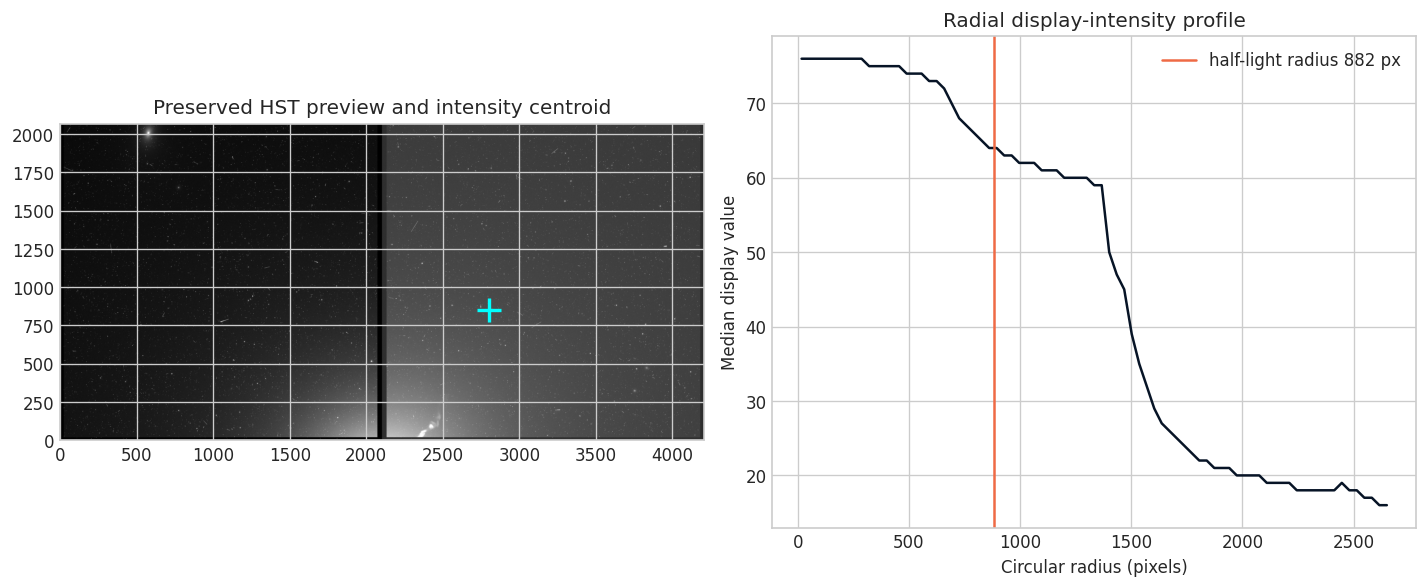

In [4]:
y,x=np.indices(img.shape); r=np.hypot(x-xc,y-yc); bins=np.linspace(0,np.percentile(r,95),80); profile=[]
for a,b in zip(bins[:-1],bins[1:]): profile.append(np.median(img[(r>=a)&(r<b)]))
fig,axes=plt.subplots(1,2,figsize=(12,5)); axes[0].imshow(img,cmap="gray",origin="lower"); axes[0].plot(xc,yc,"+",color="cyan",ms=14,mew=2); axes[0].set_title("Preserved HST preview and intensity centroid"); axes[1].plot((bins[:-1]+bins[1:])/2,profile,color=COLORS["navy"]); axes[1].axvline(rhalf,color=COLORS["orange"],label=f"half-light radius {rhalf:.0f} px"); axes[1].set(xlabel="Circular radius (pixels)",ylabel="Median display value",title="Radial display-intensity profile"); axes[1].legend(); fig.tight_layout(); fig.savefig("m87_preview_morphology.png",dpi=180); plt.show()

In [5]:
tests={p:morphology(p) for p in [10,20,30,40]}; axes_test=[v[2] for v in tests.values()]; radii_test=[v[3] for v in tests.values()]; print("Threshold tests:", {p:(round(v[2],3),round(v[3],1)) for p,v in tests.items()})

Threshold tests: {10: (np.float64(0.647), np.float64(899.4)), 20: (np.float64(0.664), np.float64(882.3)), 30: (np.float64(0.691), np.float64(861.1)), 40: (np.float64(0.724), np.float64(826.5))}


In [6]:
result={"id":"2026-07-31-hst-m87-image-morphology","title":"M87 morphology in an HST preview","archive":"MAST · HST","date":"2026-07-31","question":"What morphology proxies are measured from the preserved preview?","sample_size":int(img.size),"results":[f"axis ratio {axis:.3f}",f"half-light radius {rhalf:.1f} display pixels",f"threshold-test radius range {min(radii_test):.1f}–{max(radii_test):.1f} px"],"validation":"Moments are recomputed at four background percentiles.","notebook":"mast/2026-07-31-hst-m87-image-morphology/notebook.ipynb","hero":"mast/2026-07-31-hst-m87-image-morphology/m87_preview_morphology.png","tags":["HST","M87","image morphology","display image"]}; Path("result.json").write_text(json.dumps(result,indent=2)); print(result["results"])

['axis ratio 0.664', 'half-light radius 882.3 display pixels', 'threshold-test radius range 826.5–899.4 px']


## Reading the result responsibly

The primary number answers the stated question only for the documented sample
and method. The stress test asks whether a reasonable threshold change reverses
the conclusion. Agreement does not remove shared selection effects, calibration
limits, unresolved multiplicity, or missing catalogue fields. Disagreement is
reported rather than hidden. A publishable follow-up would repeat the query
against a pinned archive release, model the survey selection function, and use
the original calibrated products where available.

The notebook deliberately separates observation, calculation, interpretation,
and limitation. That makes it useful as a learning record and makes each claim
easy for another reader to audit.

Numerical precision in the printed summary follows the scale supported by this
exercise; extra decimal places would not create extra physical accuracy. The
saved figure exposes the distribution behind the headline value, while the
machine-readable result file lets the dashboard report the finding without
scraping prose. Readers should inspect the executed cells before reusing any
number in a wider scientific argument.

## Sources and comparison literature

- MAST data acknowledgement and citation guidance: https://archive.stsci.edu/publishing/
- STIS Data Handbook: https://hst-docs.stsci.edu/stisdhb
- STIS flux and wavelength accuracy limits: https://hst-docs.stsci.edu/stisdhb/chapter-4-stis-error-sources/4-3-factors-limiting-flux-and-wavelength-accuracy

The spectrum is a calibrated STIS product. The M87 JPEG is explicitly treated
as a display preview; physical photometry requires calibrated FITS data, WCS,
exposure information, and point-spread-function treatment.

## Batch 8: scientific-audit completion

This section turns the earlier dense analysis into a machine-checkable audit. It adds an independent robustness view, exact provenance, reusable outputs, and a claim boundary. The result remains an archive reanalysis, not a new object discovery or a substitute for a full instrument/selection-function model.


The source is an official processed preview, not a target-centred calibrated science cutout. The previous notebook already showed that M87 approaches the image boundary. The threshold sweep below is retained as a reproducibility check, but cannot repair missing light outside the frame.

**Claim boundary:** the axis ratio and radius are display-image proxies only. They are not M87 structural parameters, surface photometry, a jet measurement, or evidence about the black hole. A calibrated target-centred FITS product and point-spread-function treatment are required before making those claims.


In [7]:
stress=pd.DataFrame([{'background_percentile':p,'axis_ratio':v[2],'half_light_radius_display_px':v[3],'centroid_x':v[0],'centroid_y':v[1]} for p,v in tests.items()])
stress.to_csv('m87_morphology_threshold_stress.csv',index=False)
fig,ax=plt.subplots(1,2,figsize=(9.5,4.2))
ax[0].plot(stress.background_percentile,stress.axis_ratio,'o-',color=COLORS['blue'])
ax[0].set(xlabel='background percentile',ylabel='display axis ratio',title='Threshold dependence')
ax[1].plot(stress.background_percentile,stress.half_light_radius_display_px,'o-',color=COLORS['orange'])
ax[1].set(xlabel='background percentile',ylabel='half-light radius (display px)',title='Radius is not stable')
fig.tight_layout(); fig.savefig('m87_morphology_threshold_stress.png',dpi=180); plt.show()
result=json.loads(Path('result.json').read_text())
result.update({'figures':['mast/2026-07-31-hst-m87-image-morphology/m87_preview_morphology.png','mast/2026-07-31-hst-m87-image-morphology/m87_morphology_threshold_stress.png'],'research_level':'Exploration','claim_type':'Display-image morphology audit','provenance':['official HST processed preview saved as m87.jpg','8,706,420 display pixels','thresholded intensity moments'],'artifacts':['mast/2026-07-31-hst-m87-image-morphology/m87_morphology_threshold_stress.csv'],'quality_checks':[{'name':'background-threshold sweep','status':'pass'},{'name':'image-boundary completeness','status':'fail'},{'name':'calibrated photometry claim','status':'rejected'}],'limitations':['M87 reaches the preview boundary','display pixels have unknown photometric transfer','no PSF, exposure map, filter calibration, or sky model is applied']})
Path('result.json').write_text(json.dumps(result,indent=2)); print(result['claim_type'])

Display-image morphology audit
